In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("EDA environment initialized successfully.")

EDA environment initialized successfully.


In [3]:
import os

os.chdir(r"D:\business_analytics_project1")

print(os.getcwd())

D:\business_analytics_project1


In [4]:
# Load processed datasets

supplier_master = pd.read_csv("data/processed/supplier_master.csv")
purchase_orders = pd.read_csv("data/processed/purchase_orders_processed.csv")
quality_incidents = pd.read_csv("data/processed/quality_incidents_processed.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [5]:
# Check dimensions

print("Supplier Master:", supplier_master.shape)
print("Purchase Orders:", purchase_orders.shape)
print("Quality Incidents:", quality_incidents.shape)

Supplier Master: (40, 19)
Purchase Orders: (29666, 17)
Quality Incidents: (368, 8)


In [6]:
# Inspect the first few rows

print("SUPPLIER MASTER")
display(supplier_master.head())

print("\nPURCHASE ORDERS")
display(purchase_orders.head())

print("\nQUALITY INCIDENTS")
display(quality_incidents.head())

SUPPLIER MASTER


,supplier_id,total_orders,late_orders,late_delivery_rate,avg_delivery_delay,max_delivery_delay,avg_actual_lead_time,avg_expected_lead_time,avg_lead_time_variance,lead_time_std,quality_incidents,total_scrap_qty,quality_incident_rate,quality_incident_rate_pct,otif_orders,otif_rate,total_order_quantity,distinct_parts_supplied,critical_parts_supplied
0,SUP001,659,278,42.19,0.27,10,40.70,40.53,0.17,7.40,3,3,0.004552,0.46,343,52.05,7839,7,0
1,SUP002,763,548,71.82,2.25,12,64.90,62.56,2.34,10.91,10,14,0.013106,1.31,196,25.69,15601,6,0
2,SUP003,633,424,66.98,1.91,12,44.16,42.38,1.78,9.23,6,11,0.009479,0.95,178,28.12,9558,6,0
3,SUP004,662,288,43.50,0.26,8,35.48,35.16,0.32,6.82,6,6,0.009063,0.91,348,52.57,8703,6,0
4,SUP005,436,289,66.28,1.93,11,53.51,51.41,2.10,7.43,1,1,0.002294,0.23,123,28.21,4791,6,3



PURCHASE ORDERS


,po_id,supplier_id,site_id,part_id,order_date,promised_date,receipt_date,ordered_qty,received_qty,delivery_delay_days,late_delivery,actual_lead_time_days,lead_time_days_x,lead_time_days_y,lead_time_days,lead_time_variance_days,otif
0,PO000001,SUP004,SITE01,P00001,2022-05-02,2022-05-28,2022-05-29,16,16,1,1,27,27,27,27,0,0
1,PO000002,SUP004,SITE01,P00001,2022-07-04,2022-07-31,2022-08-02,5,5,2,1,29,27,27,27,2,0
2,PO000003,SUP004,SITE01,P00001,2022-10-17,2022-11-12,2022-11-16,5,5,4,1,30,27,27,27,3,0
3,PO000004,SUP004,SITE01,P00001,2023-02-06,2023-03-07,2023-03-09,3,3,2,1,31,27,27,27,4,0
4,PO000005,SUP004,SITE01,P00001,2023-04-03,2023-04-28,2023-04-29,5,5,1,1,26,27,27,27,-1,0



QUALITY INCIDENTS


,incident_id,incident_date,part_id,supplier_id,site_id,defect_severity,defect_type,scrap_qty
0,QI000001,2024-12-09,P00264,SUP033,SITE06,Major,Surface finish,1
1,QI000002,2022-07-17,P00185,SUP019,SITE04,Major,Surface finish,1
2,QI000003,2023-02-16,P00170,SUP001,SITE02,Minor,Material,1
3,QI000004,2023-10-10,P00164,SUP033,SITE01,Minor,Dimensional,1
4,QI000005,2025-01-11,P00297,SUP002,SITE01,Minor,Packaging,1


In [7]:
# Inspect supplier-level data

print("Supplier Master Shape:", supplier_master.shape)
print("\nColumns:")
print(supplier_master.columns.tolist())

print("\nSupplier Master Summary:")
display(supplier_master.describe(include="all").T)

Supplier Master Shape: (40, 19)

Columns:
['supplier_id', 'total_orders', 'late_orders', 'late_delivery_rate', 'avg_delivery_delay', 'max_delivery_delay', 'avg_actual_lead_time', 'avg_expected_lead_time', 'avg_lead_time_variance', 'lead_time_std', 'quality_incidents', 'total_scrap_qty', 'quality_incident_rate', 'quality_incident_rate_pct', 'otif_orders', 'otif_rate', 'total_order_quantity', 'distinct_parts_supplied', 'critical_parts_supplied']

Supplier Master Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
supplier_id,40,40,SUP001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_orders,40.0,NaN,NaN,NaN,741.65,269.148758,280.0,574.75,687.5,842.25,1311.0
late_orders,40.0,NaN,NaN,NaN,414.2,180.921459,171.0,288.75,369.5,504.5,897.0
late_delivery_rate,40.0,NaN,NaN,NaN,56.56,14.657384,38.78,43.095,56.535,68.7225,96.35
avg_delivery_delay,40.0,NaN,NaN,NaN,1.2395,1.213803,-0.08,0.2575,1.13,2.0475,6.09
max_delivery_delay,40.0,NaN,NaN,NaN,10.6,1.945409,7.0,9.0,11.0,12.0,17.0
avg_actual_lead_time,40.0,NaN,NaN,NaN,43.611,14.474397,21.71,33.255,43.045,50.27,97.37
avg_expected_lead_time,40.0,NaN,NaN,NaN,42.34525,13.352999,21.7,33.02,41.57,48.275,90.9
avg_lead_time_variance,40.0,NaN,NaN,NaN,1.2655,1.249825,-0.11,0.2875,1.095,2.055,6.47
lead_time_std,40.0,NaN,NaN,NaN,7.53925,1.447965,4.98,6.7325,7.345,8.6625,10.91


In [8]:
# Key supplier performance metrics

supplier_master[
    [
        "supplier_id",
        "total_orders",
        "late_orders",
        "late_delivery_rate",
        "avg_delivery_delay",
        "max_delivery_delay",
        "avg_actual_lead_time",
        "avg_expected_lead_time",
        "avg_lead_time_variance",
        "lead_time_std",
        "quality_incidents",
        "total_scrap_qty",
        "quality_incident_rate_pct",
        "otif_rate",
        "total_order_quantity",
        "distinct_parts_supplied",
        "critical_parts_supplied"
    ]
].head(10)

,supplier_id,total_orders,late_orders,late_delivery_rate,avg_delivery_delay,max_delivery_delay,avg_actual_lead_time,avg_expected_lead_time,avg_lead_time_variance,lead_time_std,quality_incidents,total_scrap_qty,quality_incident_rate_pct,otif_rate,total_order_quantity,distinct_parts_supplied,critical_parts_supplied
0,SUP001,659,278,42.19,0.27,10,40.70,40.53,0.17,7.40,3,3,0.46,52.05,7839,7,0
1,SUP002,763,548,71.82,2.25,12,64.90,62.56,2.34,10.91,10,14,1.31,25.69,15601,6,0
2,SUP003,633,424,66.98,1.91,12,44.16,42.38,1.78,9.23,6,11,0.95,28.12,9558,6,0
3,SUP004,662,288,43.50,0.26,8,35.48,35.16,0.32,6.82,6,6,0.91,52.57,8703,6,0
4,SUP005,436,289,66.28,1.93,11,53.51,51.41,2.10,7.43,1,1,0.23,28.21,4791,6,3
5,SUP006,1096,752,68.61,2.11,11,60.85,58.71,2.15,7.20,18,19,1.64,26.37,16781,10,0
6,SUP007,831,389,46.81,0.39,11,34.80,34.48,0.32,4.98,2,2,0.24,48.98,10503,9,2
7,SUP008,587,258,43.95,0.18,9,33.21,32.90,0.31,8.87,9,10,1.53,51.45,9797,6,2
8,SUP009,649,453,69.80,1.93,12,52.03,49.92,2.11,10.17,11,16,1.69,25.27,11741,5,0
9,SUP010,930,402,43.23,0.35,8,27.07,26.84,0.22,5.03,8,8,0.86,51.94,13221,9,1


In [9]:
# Supplier late-delivery rate distribution

print("Late Delivery Rate Summary:")
display(supplier_master["late_delivery_rate"].describe())

print("\nMedian Late Delivery Rate:",
      supplier_master["late_delivery_rate"].median())

print("Mean Late Delivery Rate:",
      supplier_master["late_delivery_rate"].mean())

Late Delivery Rate Summary:


count    40.000000
mean     56.560000
std      14.657384
min      38.780000
25%      43.095000
50%      56.535000
75%      68.722500
max      96.350000
Name: late_delivery_rate, dtype: float64


Median Late Delivery Rate: 56.535000000000004
Mean Late Delivery Rate: 56.56


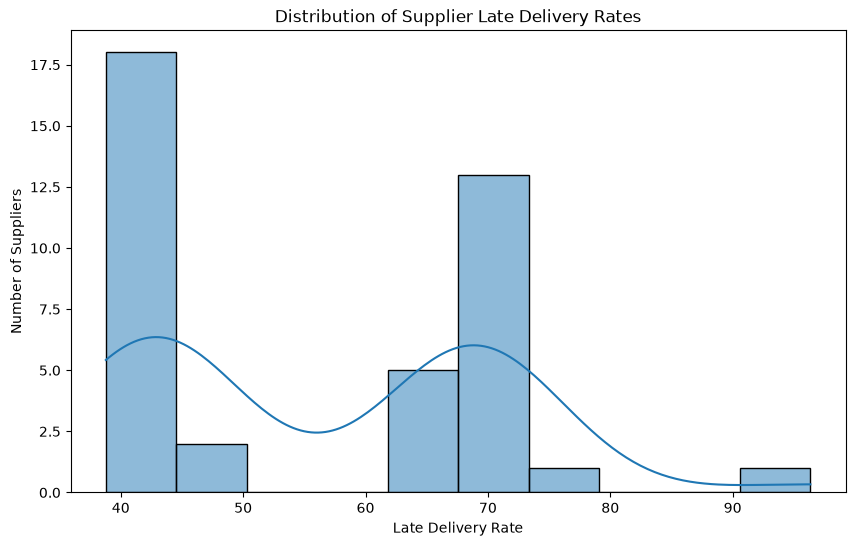

In [10]:
# Distribution of supplier late-delivery rates

plt.figure(figsize=(10, 6))

sns.histplot(
    supplier_master["late_delivery_rate"],
    bins=10,
    kde=True
)

plt.title("Distribution of Supplier Late Delivery Rates")
plt.xlabel("Late Delivery Rate")
plt.ylabel("Number of Suppliers")
plt.show()

In [11]:
# Suppliers with the highest late-delivery rates

worst_delivery_suppliers = (
    supplier_master[
        [
            "supplier_id",
            "total_orders",
            "late_orders",
            "late_delivery_rate",
            "avg_delivery_delay",
            "otif_rate"
        ]
    ]
    .sort_values("late_delivery_rate", ascending=False)
    .head(10)
)

display(worst_delivery_suppliers)

,supplier_id,total_orders,late_orders,late_delivery_rate,avg_delivery_delay,otif_rate
32,SUP033,631,608,96.35,6.09,3.01
22,SUP023,280,206,73.57,2.37,23.93
1,SUP002,763,548,71.82,2.25,25.69
25,SUP026,680,480,70.59,2.16,25.44
38,SUP039,306,215,70.26,2.18,25.16
14,SUP015,413,290,70.22,2.21,26.15
20,SUP021,523,367,70.17,2.08,26.00
8,SUP009,649,453,69.80,1.93,25.27
13,SUP014,843,583,69.16,2.08,27.05
24,SUP025,543,375,69.06,2.07,25.97


In [12]:
# Supplier OTIF rate distribution

print("OTIF Rate Summary:")
display(supplier_master["otif_rate"].describe())

print("\nMedian OTIF Rate:",
      supplier_master["otif_rate"].median())

print("Mean OTIF Rate:",
      supplier_master["otif_rate"].mean())

OTIF Rate Summary:


count    40.00000
mean     39.09975
std      14.26164
min       3.01000
25%      26.49750
50%      38.90500
75%      52.32250
max      57.60000
Name: otif_rate, dtype: float64


Median OTIF Rate: 38.905
Mean OTIF Rate: 39.09974999999999


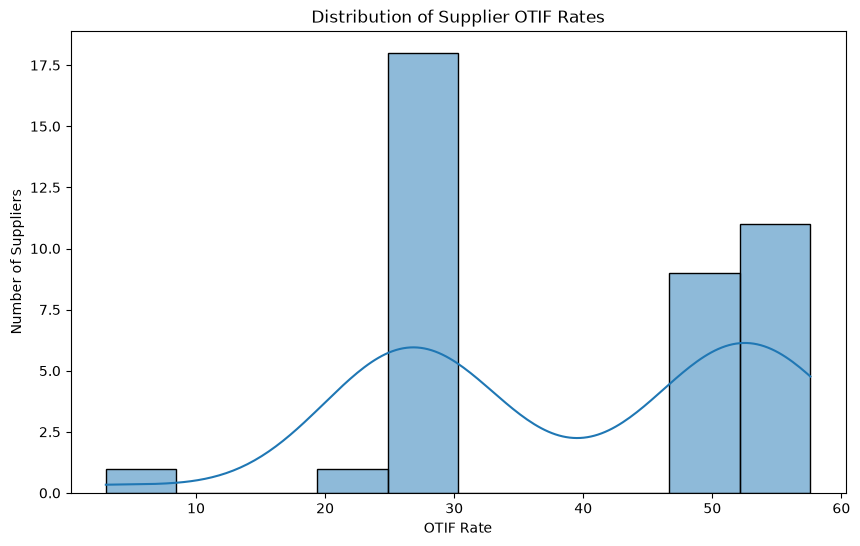

In [13]:
# Distribution of supplier OTIF rates

plt.figure(figsize=(10, 6))

sns.histplot(
    supplier_master["otif_rate"],
    bins=10,
    kde=True
)

plt.title("Distribution of Supplier OTIF Rates")
plt.xlabel("OTIF Rate")
plt.ylabel("Number of Suppliers")

plt.show()

In [14]:
# Suppliers with the lowest OTIF rates

worst_otif_suppliers = (
    supplier_master[
        [
            "supplier_id",
            "total_orders",
            "otif_orders",
            "otif_rate",
            "late_delivery_rate",
            "avg_delivery_delay"
        ]
    ]
    .sort_values("otif_rate", ascending=True)
    .head(10)
)

display(worst_otif_suppliers)

,supplier_id,total_orders,otif_orders,otif_rate,late_delivery_rate,avg_delivery_delay
32,SUP033,631,19,3.01,96.35,6.09
22,SUP023,280,67,23.93,73.57,2.37
38,SUP039,306,77,25.16,70.26,2.18
8,SUP009,649,164,25.27,69.80,1.93
25,SUP026,680,173,25.44,70.59,2.16
1,SUP002,763,196,25.69,71.82,2.25
24,SUP025,543,141,25.97,69.06,2.07
20,SUP021,523,136,26.00,70.17,2.08
14,SUP015,413,108,26.15,70.22,2.21
5,SUP006,1096,289,26.37,68.61,2.11


In [15]:
# Supplier lead-time summary

lead_time_summary = supplier_master[
    [
        "supplier_id",
        "avg_actual_lead_time",
        "avg_expected_lead_time",
        "avg_lead_time_variance",
        "lead_time_std"
    ]
].sort_values(
    "avg_lead_time_variance",
    ascending=False
)

display(lead_time_summary)

,supplier_id,avg_actual_lead_time,avg_expected_lead_time,avg_lead_time_variance,lead_time_std
32,SUP033,97.37,90.90,6.47,10.09
38,SUP039,44.05,41.70,2.35,8.89
1,SUP002,64.90,62.56,2.34,10.91
20,SUP021,61.91,59.63,2.28,6.95
22,SUP023,57.77,55.51,2.26,9.47
23,SUP024,58.53,56.27,2.26,9.39
5,SUP006,60.85,58.71,2.15,7.20
24,SUP025,46.58,44.47,2.11,6.82
8,SUP009,52.03,49.92,2.11,10.17
4,SUP005,53.51,51.41,2.10,7.43


In [16]:
# Suppliers with the highest positive lead-time variance

high_variance_suppliers = (
    supplier_master[
        [
            "supplier_id",
            "avg_actual_lead_time",
            "avg_expected_lead_time",
            "avg_lead_time_variance",
            "lead_time_std"
        ]
    ]
    .sort_values("avg_lead_time_variance", ascending=False)
    .head(10)
)

display(high_variance_suppliers)

,supplier_id,avg_actual_lead_time,avg_expected_lead_time,avg_lead_time_variance,lead_time_std
32,SUP033,97.37,90.90,6.47,10.09
38,SUP039,44.05,41.70,2.35,8.89
1,SUP002,64.90,62.56,2.34,10.91
20,SUP021,61.91,59.63,2.28,6.95
22,SUP023,57.77,55.51,2.26,9.47
23,SUP024,58.53,56.27,2.26,9.39
5,SUP006,60.85,58.71,2.15,7.20
24,SUP025,46.58,44.47,2.11,6.82
8,SUP009,52.03,49.92,2.11,10.17
4,SUP005,53.51,51.41,2.10,7.43


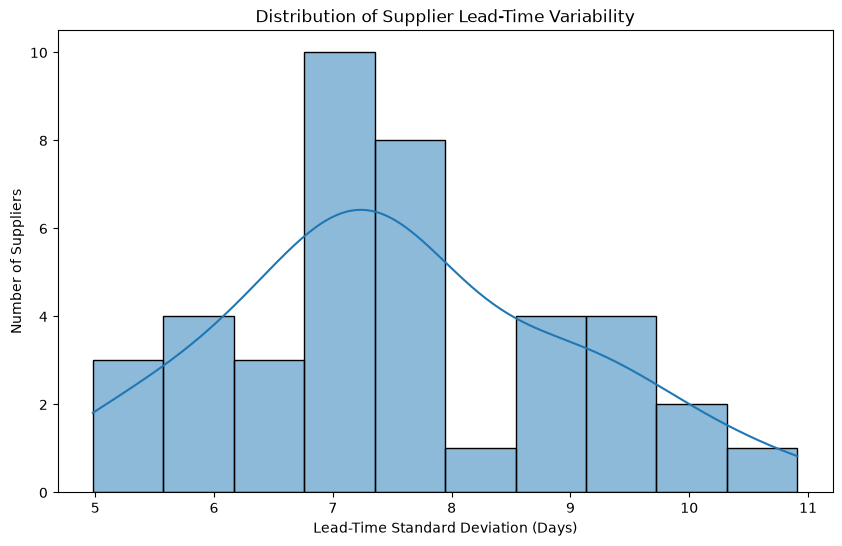

In [17]:
# Distribution of supplier lead-time standard deviation

plt.figure(figsize=(10, 6))

sns.histplot(
    supplier_master["lead_time_std"],
    bins=10,
    kde=True
)

plt.title("Distribution of Supplier Lead-Time Variability")
plt.xlabel("Lead-Time Standard Deviation (Days)")
plt.ylabel("Number of Suppliers")

plt.show()

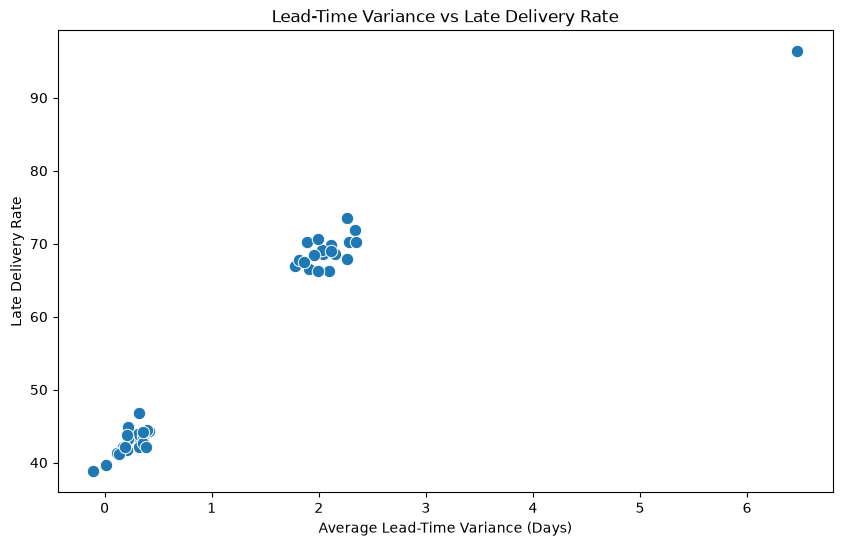

In [18]:
# Lead-time variance vs late-delivery rate

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=supplier_master,
    x="avg_lead_time_variance",
    y="late_delivery_rate",
    s=80
)

plt.title("Lead-Time Variance vs Late Delivery Rate")
plt.xlabel("Average Lead-Time Variance (Days)")
plt.ylabel("Late Delivery Rate")

plt.show()

In [19]:
# Supplier quality summary

print("Quality Incident Rate Summary:")

display(
    supplier_master[
        [
            "quality_incidents",
            "total_scrap_qty",
            "quality_incident_rate",
            "quality_incident_rate_pct"
        ]
    ].describe()
)

Quality Incident Rate Summary:


,quality_incidents,total_scrap_qty,quality_incident_rate,quality_incident_rate_pct
count,40.000000,40.000000,40.000000,40.000000
mean,9.200000,11.400000,0.012567,1.255750
std,5.145075,6.348026,0.005028,0.502123
min,1.000000,1.000000,0.002294,0.230000
25%,6.000000,7.000000,0.008948,0.897500
50%,8.000000,10.500000,0.013037,1.300000
75%,11.000000,14.250000,0.016361,1.632500
max,24.000000,29.000000,0.025000,2.500000


In [20]:
# Suppliers with the highest quality incident rates

worst_quality_suppliers = (
    supplier_master[
        [
            "supplier_id",
            "total_orders",
            "quality_incidents",
            "total_scrap_qty",
            "quality_incident_rate_pct"
        ]
    ]
    .sort_values(
        "quality_incident_rate_pct",
        ascending=False
    )
    .head(10)
)

display(worst_quality_suppliers)

,supplier_id,total_orders,quality_incidents,total_scrap_qty,quality_incident_rate_pct
22,SUP023,280,7,7,2.50
23,SUP024,821,16,16,1.95
26,SUP027,1311,24,29,1.83
17,SUP018,607,11,11,1.81
39,SUP040,1215,22,26,1.81
32,SUP033,631,11,15,1.74
33,SUP034,578,10,13,1.73
8,SUP009,649,11,16,1.69
12,SUP013,1156,19,19,1.64
5,SUP006,1096,18,19,1.64


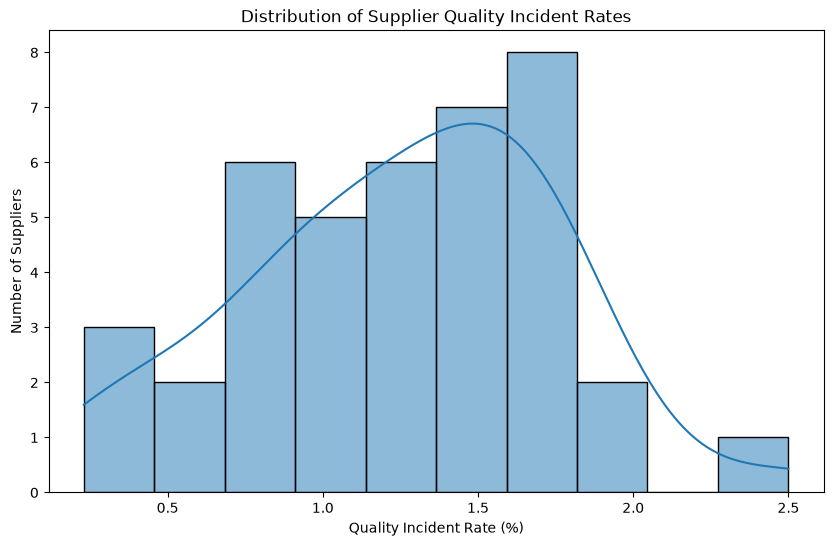

In [21]:
# Distribution of supplier quality incident rates

plt.figure(figsize=(10, 6))

sns.histplot(
    supplier_master["quality_incident_rate_pct"],
    bins=10,
    kde=True
)

plt.title("Distribution of Supplier Quality Incident Rates")
plt.xlabel("Quality Incident Rate (%)")
plt.ylabel("Number of Suppliers")

plt.show()

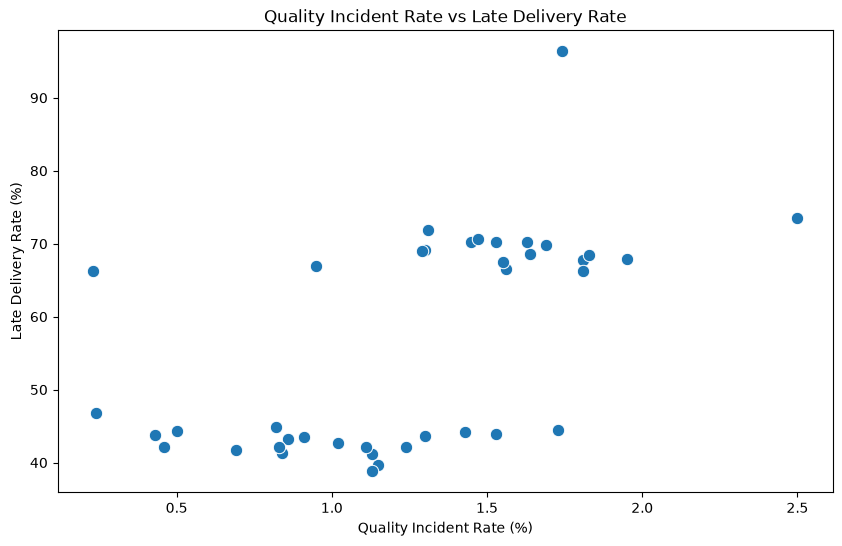

In [22]:
# Quality incident rate vs late delivery rate

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=supplier_master,
    x="quality_incident_rate_pct",
    y="late_delivery_rate",
    s=80
)

plt.title("Quality Incident Rate vs Late Delivery Rate")
plt.xlabel("Quality Incident Rate (%)")
plt.ylabel("Late Delivery Rate (%)")

plt.show()

In [23]:
# Critical-part exposure summary

print("Critical Parts Supplied Summary:")

display(
    supplier_master["critical_parts_supplied"].describe()
)

Critical Parts Supplied Summary:


count    40.000000
mean      1.200000
std       1.324329
min       0.000000
25%       0.000000
50%       1.000000
75%       2.000000
max       5.000000
Name: critical_parts_supplied, dtype: float64

In [24]:
# Suppliers supplying the highest number of critical parts

critical_exposure = (
    supplier_master[
        [
            "supplier_id",
            "critical_parts_supplied",
            "distinct_parts_supplied",
            "total_orders",
            "late_delivery_rate",
            "otif_rate",
            "quality_incident_rate_pct"
        ]
    ]
    .sort_values(
        "critical_parts_supplied",
        ascending=False
    )
)

display(critical_exposure.head(15))

,supplier_id,critical_parts_supplied,distinct_parts_supplied,total_orders,late_delivery_rate,otif_rate,quality_incident_rate_pct
11,SUP012,5,14,1163,41.79,54.69,0.69
14,SUP015,4,7,413,70.22,26.15,1.45
35,SUP036,4,8,840,42.14,53.57,0.83
4,SUP005,3,6,436,66.28,28.21,0.23
12,SUP013,3,13,1156,68.60,27.94,1.64
29,SUP030,3,12,1171,42.10,53.12,1.11
7,SUP008,2,6,587,43.95,51.45,1.53
6,SUP007,2,9,831,46.81,48.98,0.24
38,SUP039,2,4,306,70.26,25.16,1.63
33,SUP034,2,7,578,44.46,51.04,1.73


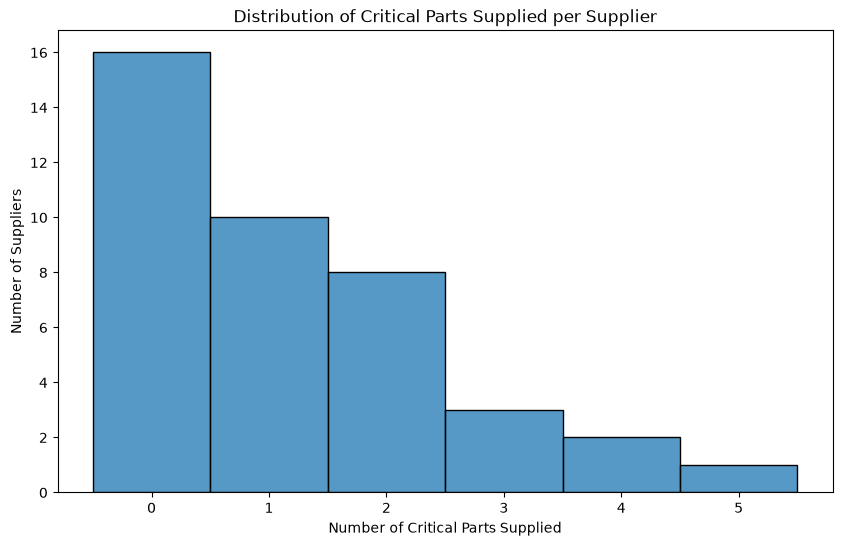

In [25]:
# Distribution of critical parts supplied

plt.figure(figsize=(10, 6))

sns.histplot(
    supplier_master["critical_parts_supplied"],
    bins=10,
    discrete=True
)

plt.title("Distribution of Critical Parts Supplied per Supplier")
plt.xlabel("Number of Critical Parts Supplied")
plt.ylabel("Number of Suppliers")

plt.show()

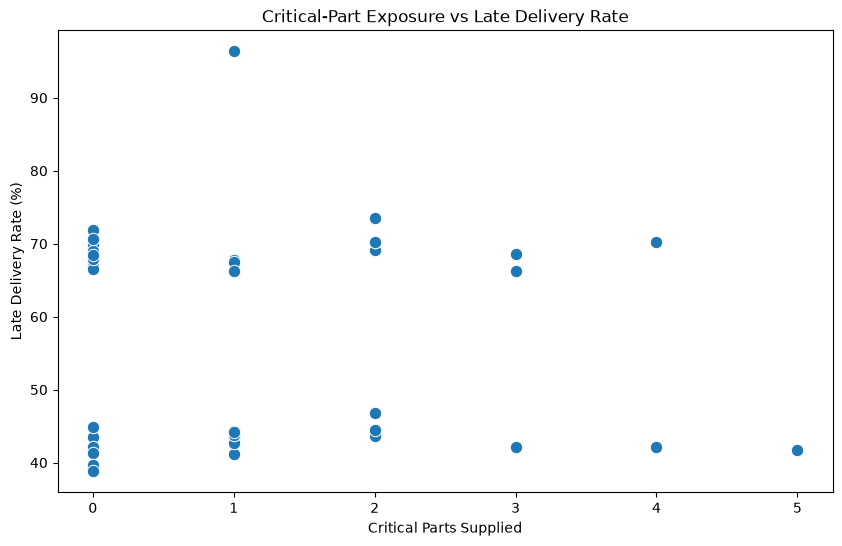

In [26]:
# Critical-part exposure vs late delivery rate

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=supplier_master,
    x="critical_parts_supplied",
    y="late_delivery_rate",
    s=80
)

plt.title("Critical-Part Exposure vs Late Delivery Rate")
plt.xlabel("Critical Parts Supplied")
plt.ylabel("Late Delivery Rate (%)")

plt.show()

In [27]:
# Select key supplier-level metrics for relationship analysis

relationship_data = supplier_master[
    [
        "late_delivery_rate",
        "otif_rate",
        "avg_lead_time_variance",
        "lead_time_std",
        "quality_incident_rate_pct",
        "critical_parts_supplied"
    ]
]

display(relationship_data.corr(method="spearman"))

,late_delivery_rate,otif_rate,avg_lead_time_variance,lead_time_std,quality_incident_rate_pct,critical_parts_supplied
late_delivery_rate,1.000000,-0.985694,0.913784,0.450230,0.604645,0.021213
otif_rate,-0.985694,1.000000,-0.905942,-0.450439,-0.604673,0.039187
avg_lead_time_variance,0.913784,-0.905942,1.000000,0.491669,0.629378,0.058814
lead_time_std,0.450230,-0.450439,0.491669,1.000000,0.361423,-0.225609
quality_incident_rate_pct,0.604645,-0.604673,0.629378,0.361423,1.000000,-0.066946
critical_parts_supplied,0.021213,0.039187,0.058814,-0.225609,-0.066946,1.000000


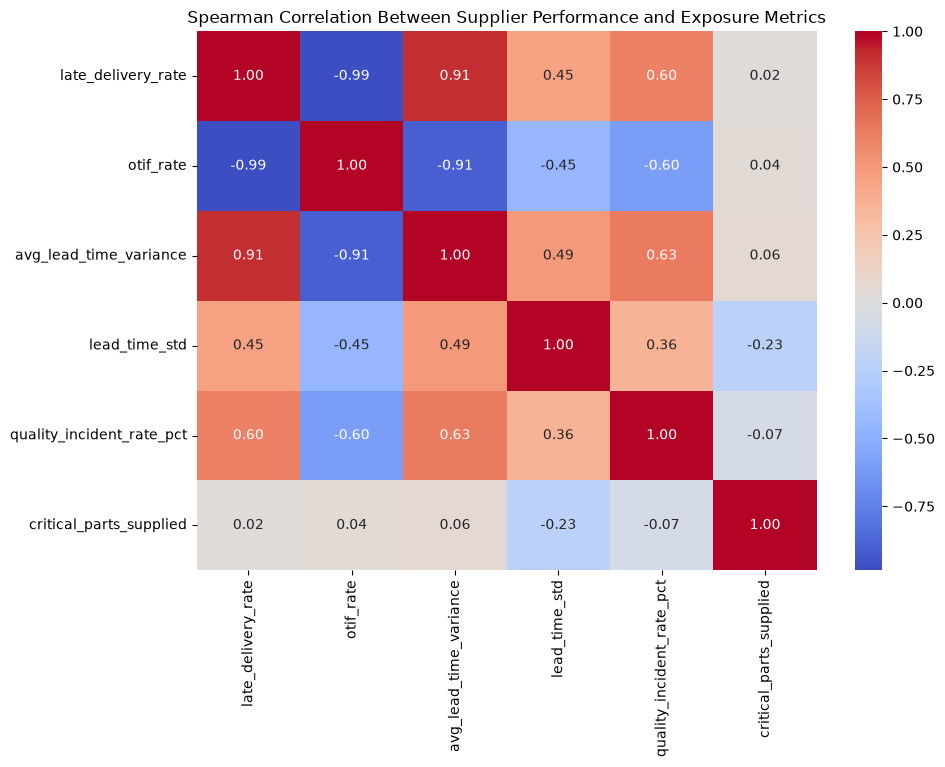

In [28]:
# Correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    relationship_data.corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation Between Supplier Performance and Exposure Metrics")

plt.show()

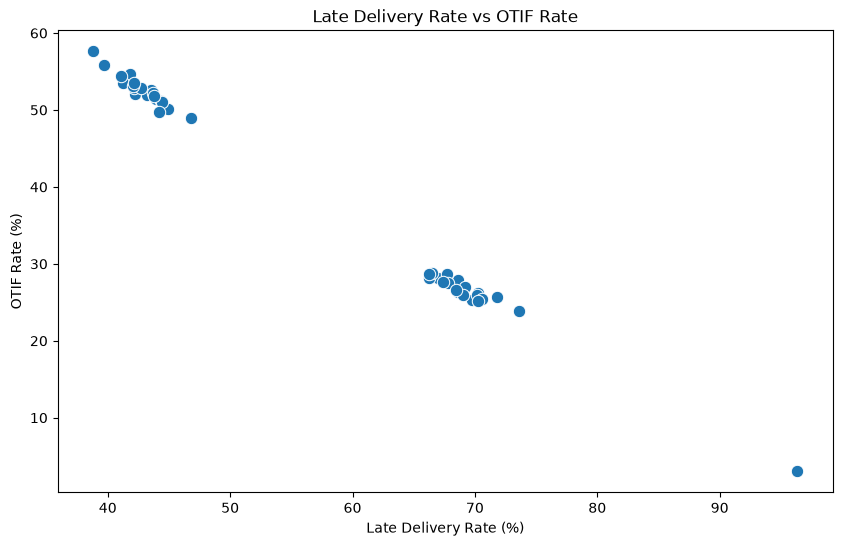

In [29]:
# Late delivery rate vs OTIF rate

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=supplier_master,
    x="late_delivery_rate",
    y="otif_rate",
    s=80
)

plt.title("Late Delivery Rate vs OTIF Rate")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("OTIF Rate (%)")

plt.show()

In [30]:
# Suppliers with critical-part exposure and poor delivery performance

critical_supplier_candidates = (
    supplier_master[
        supplier_master["critical_parts_supplied"] > 0
    ][
        [
            "supplier_id",
            "critical_parts_supplied",
            "distinct_parts_supplied",
            "total_orders",
            "late_delivery_rate",
            "otif_rate",
            "avg_lead_time_variance",
            "lead_time_std",
            "quality_incident_rate_pct"
        ]
    ]
    .sort_values(
        ["late_delivery_rate", "critical_parts_supplied"],
        ascending=[False, False]
    )
)

display(critical_supplier_candidates)

,supplier_id,critical_parts_supplied,distinct_parts_supplied,total_orders,late_delivery_rate,otif_rate,avg_lead_time_variance,lead_time_std,quality_incident_rate_pct
32,SUP033,1,7,631,96.35,3.01,6.47,10.09,1.74
22,SUP023,2,4,280,73.57,23.93,2.26,9.47,2.50
38,SUP039,2,4,306,70.26,25.16,2.35,8.89,1.63
14,SUP015,4,7,413,70.22,26.15,1.89,6.00,1.45
20,SUP021,2,6,523,70.17,26.00,2.28,6.95,1.53
13,SUP014,2,9,843,69.16,27.05,2.03,8.37,1.30
12,SUP013,3,13,1156,68.60,27.94,2.04,7.17,1.64
17,SUP018,1,6,607,67.71,28.67,1.82,6.89,1.81
37,SUP038,1,8,967,67.43,27.61,1.86,6.47,1.55
4,SUP005,3,6,436,66.28,28.21,2.10,7.43,0.23


In [31]:
# Load parts master for critical-part analysis

parts_master = pd.read_csv("data/raw/parts_master.csv")

print("Parts Master Shape:", parts_master.shape)

display(
    parts_master[
        [
            "part_id",
            "part_family",
            "criticality_class",
            "supplier_id_primary"
        ]
    ].head()
)

Parts Master Shape: (300, 9)


,part_id,part_family,criticality_class,supplier_id_primary
0,P00001,Electrical,B,SUP004
1,P00002,Cabin,C,SUP028
2,P00003,Avionics,C,SUP040
3,P00004,Electrical,A,SUP034
4,P00005,Cabin,C,SUP024


In [32]:
# Critical parts and their primary suppliers

critical_parts = parts_master[
    parts_master["criticality_class"] == "A"
][
    [
        "part_id",
        "part_family",
        "supplier_id_primary"
    ]
].copy()

print("Number of critical parts:", len(critical_parts))

display(critical_parts)

Number of critical parts: 48


,part_id,part_family,supplier_id_primary
3,P00004,Electrical,SUP034
8,P00009,Structure,SUP012
12,P00013,Avionics,SUP012
14,P00015,Engine,SUP019
16,P00017,Cabin,SUP031
21,P00022,Hydraulics,SUP038
22,P00023,Structure,SUP029
23,P00024,Fasteners,SUP015
28,P00029,Structure,SUP036
34,P00035,Hydraulics,SUP030


In [33]:
# Critical-part concentration by primary supplier

critical_supplier_concentration = (
    critical_parts
    .groupby("supplier_id_primary")
    .agg(
        critical_parts_count=("part_id", "nunique")
    )
    .reset_index()
    .sort_values(
        "critical_parts_count",
        ascending=False
    )
)

display(critical_supplier_concentration)

,supplier_id_primary,critical_parts_count
4,SUP012,5
7,SUP015,4
19,SUP036,4
0,SUP005,3
14,SUP030,3
5,SUP013,3
1,SUP007,2
2,SUP008,2
17,SUP034,2
6,SUP014,2


In [34]:
# Supplier redundancy for critical parts

critical_part_ids = critical_parts["part_id"]

critical_po_supply = purchase_orders[
    purchase_orders["part_id"].isin(critical_part_ids)
].copy()

critical_part_supplier_count = (
    critical_po_supply
    .groupby("part_id")
    .agg(
        supplier_count=("supplier_id", "nunique"),
        total_orders=("po_id", "nunique")
    )
    .reset_index()
    .sort_values(
        ["supplier_count", "total_orders"],
        ascending=[True, False]
    )
)

display(critical_part_supplier_count)

,part_id,supplier_count,total_orders
18,P00085,1,84
4,P00017,1,82
37,P00233,1,82
44,P00271,1,72
20,P00111,1,70
15,P00069,1,64
16,P00073,1,54
30,P00183,1,52
23,P00125,1,51
34,P00219,1,51


In [36]:
# Check supplier redundancy across all parts

part_supplier_counts = (
    purchase_orders
    .groupby("part_id")["supplier_id"]
    .nunique()
    .reset_index(name="supplier_count")
)

print("Supplier count distribution across all parts:")
display(
    part_supplier_counts["supplier_count"]
    .value_counts()
    .sort_index()
)

print("\nParts supplied by more than one supplier:")
display(
    part_supplier_counts[
        part_supplier_counts["supplier_count"] > 1
    ].sort_values("supplier_count", ascending=False)
)

Supplier count distribution across all parts:


supplier_count
1    300
Name: count, dtype: int64


Parts supplied by more than one supplier:


,part_id,supplier_count


In [37]:
# Map critical parts to their supplier performance

critical_part_risk_view = (
    critical_parts
    .merge(
        supplier_master[
            [
                "supplier_id",
                "late_delivery_rate",
                "otif_rate",
                "avg_lead_time_variance",
                "lead_time_std",
                "quality_incident_rate_pct"
            ]
        ],
        left_on="supplier_id_primary",
        right_on="supplier_id",
        how="left"
    )
    .drop(columns=["supplier_id"])
    .sort_values(
        ["late_delivery_rate", "quality_incident_rate_pct"],
        ascending=[False, False]
    )
)

display(critical_part_risk_view)

,part_id,part_family,supplier_id_primary,late_delivery_rate,otif_rate,avg_lead_time_variance,lead_time_std,quality_incident_rate_pct
43,P00264,Structure,SUP033,96.35,3.01,6.47,10.09,1.74
35,P00220,Electrical,SUP023,73.57,23.93,2.26,9.47,2.50
44,P00271,Cabin,SUP023,73.57,23.93,2.26,9.47,2.50
18,P00085,Cabin,SUP039,70.26,25.16,2.35,8.89,1.63
20,P00111,Cabin,SUP039,70.26,25.16,2.35,8.89,1.63
7,P00024,Fasteners,SUP015,70.22,26.15,1.89,6.00,1.45
21,P00113,Engine,SUP015,70.22,26.15,1.89,6.00,1.45
41,P00247,Electrical,SUP015,70.22,26.15,1.89,6.00,1.45
42,P00250,Structure,SUP015,70.22,26.15,1.89,6.00,1.45
34,P00219,Avionics,SUP021,70.17,26.00,2.28,6.95,1.53


In [38]:
# Highest-exposure critical parts based on supplier late-delivery performance

display(
    critical_part_risk_view[
        [
            "part_id",
            "part_family",
            "supplier_id_primary",
            "late_delivery_rate",
            "otif_rate",
            "avg_lead_time_variance",
            "lead_time_std",
            "quality_incident_rate_pct"
        ]
    ].head(15)
)

,part_id,part_family,supplier_id_primary,late_delivery_rate,otif_rate,avg_lead_time_variance,lead_time_std,quality_incident_rate_pct
43,P00264,Structure,SUP033,96.35,3.01,6.47,10.09,1.74
35,P00220,Electrical,SUP023,73.57,23.93,2.26,9.47,2.50
44,P00271,Cabin,SUP023,73.57,23.93,2.26,9.47,2.50
18,P00085,Cabin,SUP039,70.26,25.16,2.35,8.89,1.63
20,P00111,Cabin,SUP039,70.26,25.16,2.35,8.89,1.63
7,P00024,Fasteners,SUP015,70.22,26.15,1.89,6.00,1.45
21,P00113,Engine,SUP015,70.22,26.15,1.89,6.00,1.45
41,P00247,Electrical,SUP015,70.22,26.15,1.89,6.00,1.45
42,P00250,Structure,SUP015,70.22,26.15,1.89,6.00,1.45
34,P00219,Avionics,SUP021,70.17,26.00,2.28,6.95,1.53


In [39]:
# Supplier business exposure vs delivery performance

supplier_exposure_view = (
    supplier_master[
        [
            "supplier_id",
            "total_orders",
            "total_order_quantity",
            "distinct_parts_supplied",
            "critical_parts_supplied",
            "late_delivery_rate",
            "otif_rate",
            "avg_lead_time_variance",
            "quality_incident_rate_pct"
        ]
    ]
    .sort_values(
        "total_order_quantity",
        ascending=False
    )
)

display(supplier_exposure_view.head(15))

,supplier_id,total_orders,total_order_quantity,distinct_parts_supplied,critical_parts_supplied,late_delivery_rate,otif_rate,avg_lead_time_variance,quality_incident_rate_pct
26,SUP027,1311,23791,11,0,68.42,26.54,1.96,1.83
16,SUP017,1306,21270,12,0,41.27,53.45,0.12,0.84
37,SUP038,967,18714,8,1,67.43,27.61,1.86,1.55
39,SUP040,1215,16905,11,1,66.26,28.72,1.99,1.81
5,SUP006,1096,16781,10,0,68.61,26.37,2.15,1.64
29,SUP030,1171,16462,12,3,42.10,53.12,0.19,1.11
23,SUP024,821,16150,6,0,67.84,27.53,2.26,1.95
1,SUP002,763,15601,6,0,71.82,25.69,2.34,1.31
35,SUP036,840,15202,8,4,42.14,53.57,0.39,0.83
11,SUP012,1163,14886,14,5,41.79,54.69,0.21,0.69


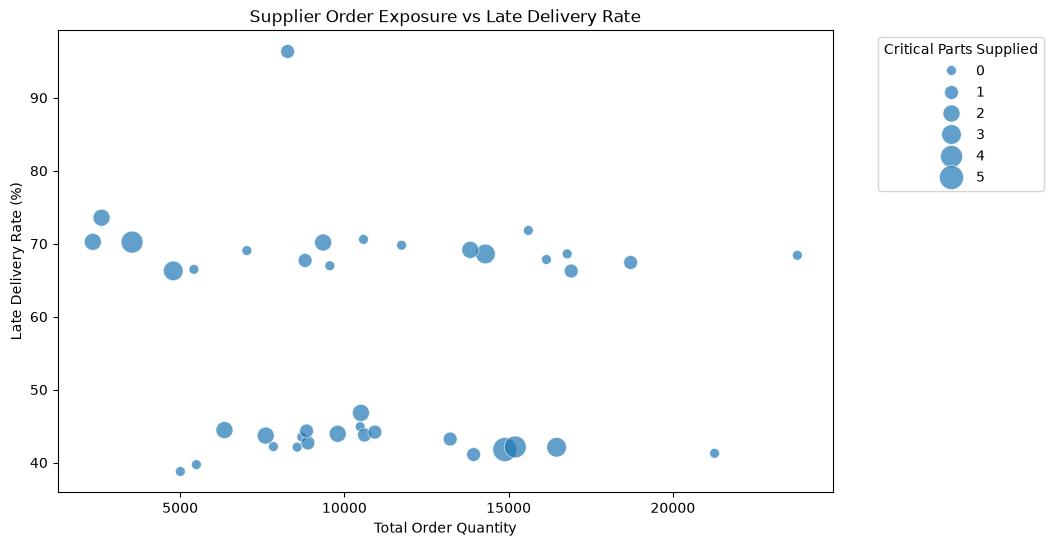

In [40]:
# Business order exposure vs late delivery rate

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=supplier_master,
    x="total_order_quantity",
    y="late_delivery_rate",
    size="critical_parts_supplied",
    sizes=(50, 300),
    alpha=0.7
)

plt.title("Supplier Order Exposure vs Late Delivery Rate")
plt.xlabel("Total Order Quantity")
plt.ylabel("Late Delivery Rate (%)")
plt.legend(
    title="Critical Parts Supplied",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

In [41]:
# Consolidated supplier EDA view

supplier_eda_summary = supplier_master[
    [
        "supplier_id",
        "total_orders",
        "total_order_quantity",
        "distinct_parts_supplied",
        "critical_parts_supplied",
        "late_delivery_rate",
        "otif_rate",
        "avg_delivery_delay",
        "avg_lead_time_variance",
        "lead_time_std",
        "quality_incidents",
        "quality_incident_rate_pct"
    ]
].copy()

supplier_eda_summary = supplier_eda_summary.sort_values(
    "late_delivery_rate",
    ascending=False
)

display(supplier_eda_summary)

,supplier_id,total_orders,total_order_quantity,distinct_parts_supplied,critical_parts_supplied,late_delivery_rate,otif_rate,avg_delivery_delay,avg_lead_time_variance,lead_time_std,quality_incidents,quality_incident_rate_pct
32,SUP033,631,8272,7,1,96.35,3.01,6.09,6.47,10.09,11,1.74
22,SUP023,280,2607,4,2,73.57,23.93,2.37,2.26,9.47,7,2.50
1,SUP002,763,15601,6,0,71.82,25.69,2.25,2.34,10.91,10,1.31
25,SUP026,680,10582,7,0,70.59,25.44,2.16,1.99,9.25,10,1.47
38,SUP039,306,2342,4,2,70.26,25.16,2.18,2.35,8.89,5,1.63
14,SUP015,413,3536,7,4,70.22,26.15,2.21,1.89,6.00,6,1.45
20,SUP021,523,9353,6,2,70.17,26.00,2.08,2.28,6.95,8,1.53
8,SUP009,649,11741,5,0,69.80,25.27,1.93,2.11,10.17,11,1.69
13,SUP014,843,13834,9,2,69.16,27.05,2.08,2.03,8.37,11,1.30
24,SUP025,543,7031,5,0,69.06,25.97,2.07,2.11,6.82,7,1.29


In [42]:
# Summary statistics for the major supplier dimensions

display(
    supplier_eda_summary.describe().T
)

,count,mean,std,min,25%,50%,75%,max
total_orders,40.0,741.65000,269.148758,280.00,574.7500,687.500,842.2500,1311.00
total_order_quantity,40.0,10867.47500,5000.026872,2342.00,7780.2500,10139.000,14441.2500,23791.00
distinct_parts_supplied,40.0,7.50000,2.521701,4.00,6.0000,7.000,9.0000,14.00
critical_parts_supplied,40.0,1.20000,1.324329,0.00,0.0000,1.000,2.0000,5.00
late_delivery_rate,40.0,56.56000,14.657384,38.78,43.0950,56.535,68.7225,96.35
otif_rate,40.0,39.09975,14.261640,3.01,26.4975,38.905,52.3225,57.60
avg_delivery_delay,40.0,1.23950,1.213803,-0.08,0.2575,1.130,2.0475,6.09
avg_lead_time_variance,40.0,1.26550,1.249825,-0.11,0.2875,1.095,2.0550,6.47
lead_time_std,40.0,7.53925,1.447965,4.98,6.7325,7.345,8.6625,10.91
quality_incidents,40.0,9.20000,5.145075,1.00,6.0000,8.000,11.0000,24.00
